<a href="https://colab.research.google.com/github/Ghhaidaa/Data-Mining-Project-/blob/main/Reports/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 2: Data Analysis and Preprocessing**

## 0. Setup and Dataset Loading

In this section, the required Python libraries are imported and the raw dataset is loaded.
The original dataset will remain unchanged throughout Phase 2, and a separate copy will be used later for preprocessing.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the raw dataset
df_raw = pd.read_csv("https://raw.githubusercontent.com/Ghhaidaa/Data-Mining-Project-/main/Dataset/Raw_dataset.csv")

# Display a snapshot of the raw dataset
df_raw.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


## **1. Data Analysis**

In this section, the dataset is analyzed using statistical summaries and different visualization techniques to understand its characteristics, distributions, missing values, outliers, variable relationships, and class distribution. The findings will help identify the preprocessing needed for the dataset.

### 1.1 Statistical Summary

In [6]:
numerical_attributes = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'final_exam_score'
]

df_raw[numerical_attributes].describe()

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.570700,85.092300,6.799500,69.740900,83.543500
std,1.478559,9.270685,1.203527,12.613425,10.341333
min,0.500000,54.800000,3.200000,31.300000,46.800000
25%,2.600000,78.800000,5.900000,61.000000,76.075000
50%,3.600000,85.200000,6.800000,69.600000,83.800000
75%,4.500000,91.900000,7.600000,78.400000,91.525000
max,8.100000,100.000000,10.000000,100.000000,100.000000


The statistical summary provides an overview of the dataset including mean, standard deviation, minimum, and maximum values. This helps in understanding the central tendency and spread of the numeric attributes.

### 1.2 Variable Distributions

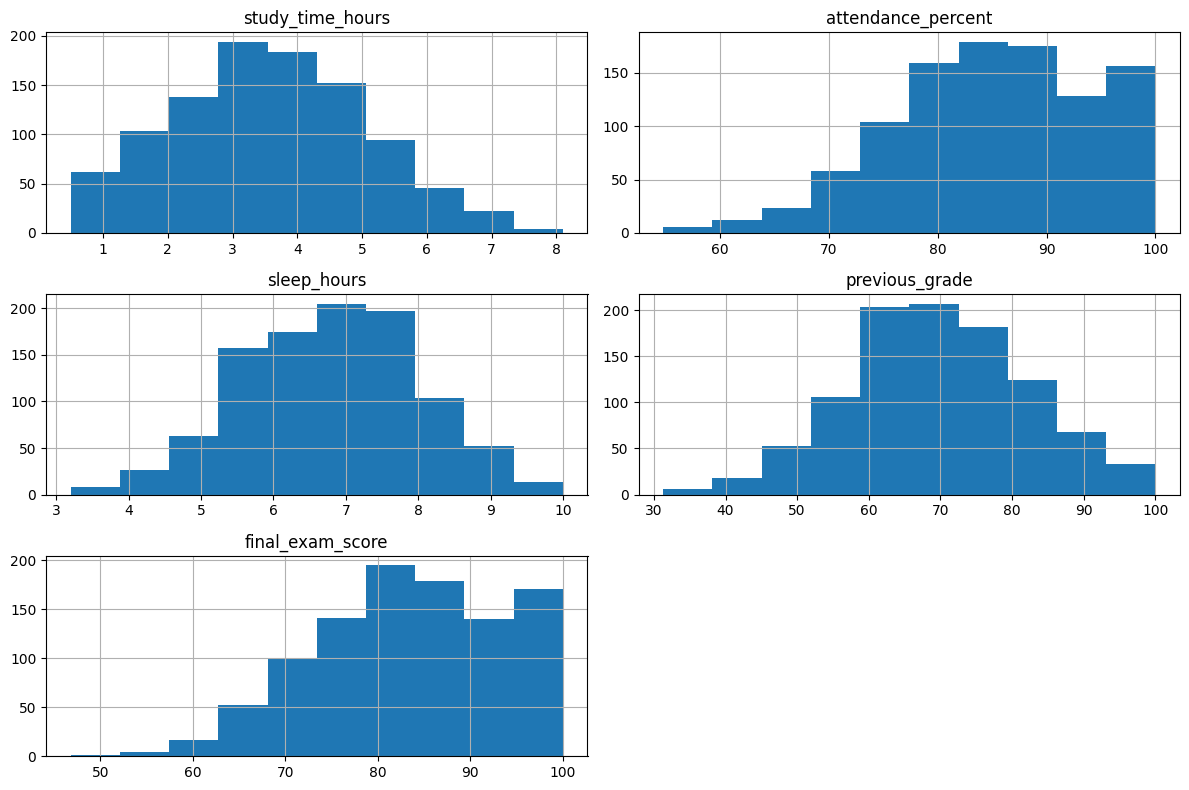

In [7]:
import matplotlib.pyplot as plt

df_raw[numerical_attributes].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

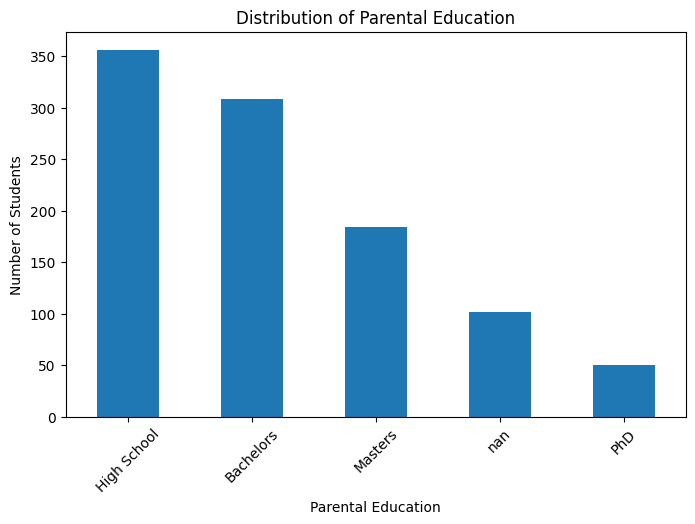

In [3]:
df_raw['parental_education'].value_counts(dropna=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Distribution of Parental Education')
plt.xlabel('Parental Education')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.show()

### **Variable Distribution Analysis:**
The histogram of study_time_hours shows that most students study around 3–4 hours, while fewer students have very low or very high study times. The attendance_percent histogram shows that most students have relatively high attendance, mainly between 80% and 100%. The sleep_hours histogram shows that most students sleep around 6–8 hours, with fewer students at the lower and higher ends. The previous_grade histogram shows that most students have previous grades around 60–80, while very low and very high grades occur less frequently. Finally, the final_exam_score histogram shows that most students achieved relatively high scores, mainly between 75 and 100. Overall, these distributions help us understand the range and pattern of each numerical attribute and identify whether preprocessing may be needed.

The bar plot shows the distribution of the parental education categories. It also highlights the presence of missing values in this categorical attribute. Since 10.2% of the values are missing, a categorical imputation technique is required before further analysis.

### 1.3 Missing Values Analysis



Missing values were examined to identify attributes that contain incomplete observations. The number of missing values in each attribute was calculated using the `isnull().sum()` function.

In [ ]:
# Check the number of missing values in each attribute

missing_values = df_raw.isnull().sum()

print("Missing values in each attribute:")
print(missing_values)

Missing values in each attribute:
student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


In [ ]:
# Calculate the percentage of missing values

missing_percentage = (df_raw.isnull().sum() / len(df_raw)) * 100

print("Percentage of missing values:")
print(missing_percentage[missing_percentage > 0])

Percentage of missing values:
parental_education    10.2
dtype: float64


### **Missing Values Results**

The analysis shows that the `parental_education` attribute contains 102 missing values, which represents 10.2% of the dataset. The remaining attributes do not contain missing values.

Since `parental_education` is a categorical attribute, the missing values should be handled using an appropriate categorical imputation method during the preprocessing stage. The raw dataset is kept unchanged at this stage.

### 1.4 Outlier Analysis



Outliers were examined in the numerical attributes to identify observations that are unusually high or low compared with the rest of the data.

In [ ]:
# Select numerical attributes for outlier analysis

numerical_columns = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'final_exam_score'
]

print("Numerical attributes used for outlier analysis:")
print(numerical_columns)

Numerical attributes used for outlier analysis:
['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']


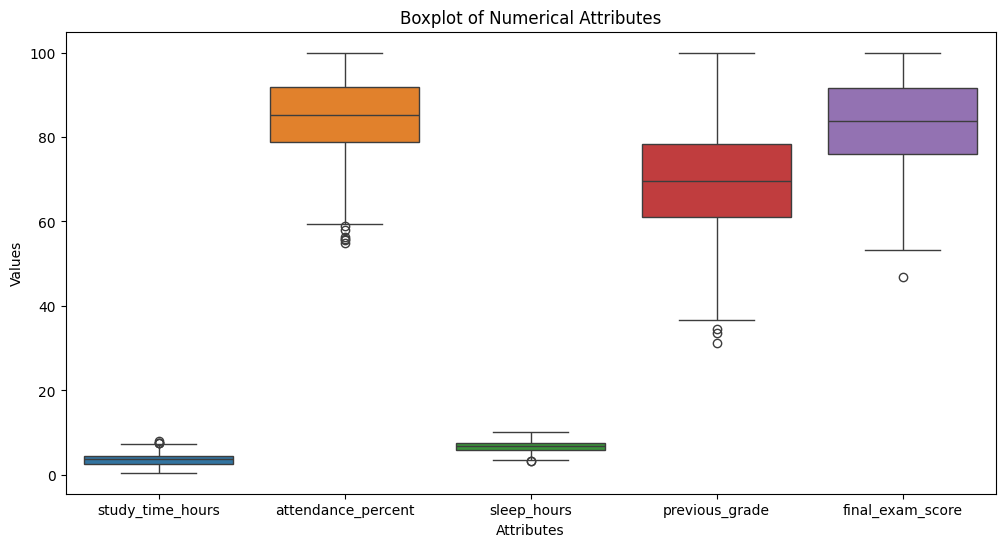

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_raw[numerical_columns])

plt.title("Boxplot of Numerical Attributes")
plt.xlabel("Attributes")
plt.ylabel("Values")

plt.show()

In [ ]:
# Detect outliers using the IQR method

outlier_summary = {}

for column in numerical_columns:
    Q1 = df_raw[column].quantile(0.25)
    Q3 = df_raw[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_raw[
        (df_raw[column] < lower_bound) |
        (df_raw[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

print("Number of outliers in each numerical attribute:")

for column, count in outlier_summary.items():
    print(f"{column}: {count}")

Number of outliers in each numerical attribute:
study_time_hours: 4
attendance_percent: 6
sleep_hours: 2
previous_grade: 3
final_exam_score: 1


### **Outliers Results**

The boxplot and IQR method were used to identify potential outliers in the numerical attributes. The analysis examined `study_time_hours`, `attendance_percent`, `sleep_hours`, `previous_grade`, and `final_exam_score`.

The detected outliers were reviewed as potential unusual observations. An outlier does not necessarily represent an incorrect value; it may be a valid observation that differs from the majority of the students.

The detected outliers were not removed because their values are still within plausible ranges for the corresponding attributes and do not necessarily represent data-entry errors or noise. Removing them without evidence could result in the loss of valid student observations. Therefore, they were retained in the dataset.

### 1.5 Scatter Plot Analysis

A scatter plot is used to examine the relationship between study time and final exam score.

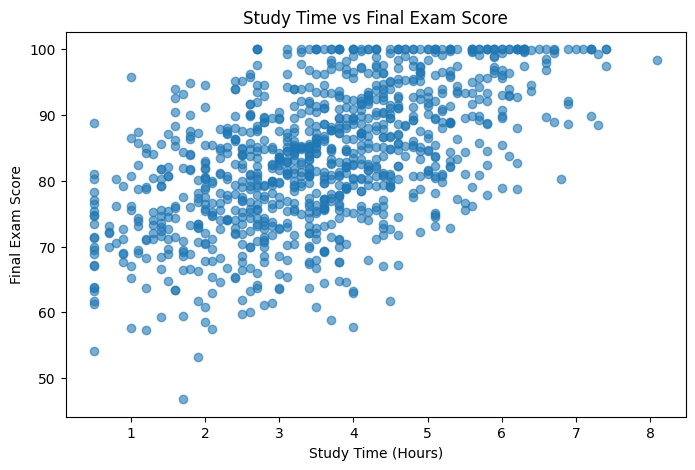

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df_raw['study_time_hours'], df_raw['final_exam_score'], alpha=0.6)

plt.xlabel('Study Time (Hours)')
plt.ylabel('Final Exam Score')
plt.title('Study Time vs Final Exam Score')

plt.show()

In [ ]:
correlation = df_raw['study_time_hours'].corr(df_raw['final_exam_score'])

print("Correlation between study time and final exam score:", round(correlation, 3))

Correlation between study time and final exam score: 0.568


**Interpretation:**

The scatter plot shows a positive relationship between study time and final exam score. In general, students who spend more hours studying tend to achieve higher final exam scores. The correlation coefficient is approximately 0.568, indicating a moderate positive relationship between the two variables.

Although the relationship is noticeable, the points are not perfectly aligned, which suggests that study time is not the only factor affecting students' final exam scores. Other attributes may also contribute to academic performance.

This plot does not indicate a direct need for preprocessing, but it helps us understand the relationship between important numerical attributes in the dataset.

### 1.6 Class Label Distribution

The distribution of the class label (`final_grade`) is analyzed to determine how the different grade classes are represented in the dataset.

In [ ]:
# Count the number of instances in each class
class_counts = df_raw['final_grade'].value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

Class Distribution:
final_grade
A    284
B    354
C    261
D     89
F     12
Name: count, dtype: int64


In [ ]:
# Calculate the percentage of each class
class_percentages = df_raw['final_grade'].value_counts(normalize=True).sort_index() * 100

print("Class Distribution (%):")
print(class_percentages.round(2))

Class Distribution (%):
final_grade
A    28.4
B    35.4
C    26.1
D     8.9
F     1.2
Name: proportion, dtype: float64


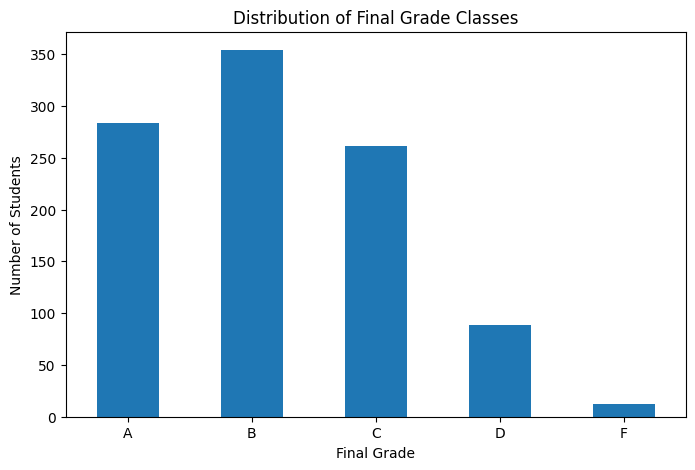

In [ ]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind='bar')

plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.title('Distribution of Final Grade Classes')
plt.xticks(rotation=0)

plt.show()

**Interpretation:**

The bar plot shows that the class label (`final_grade`) is not evenly distributed across the five grade categories. Grade B is the most frequent class with 354 students (35.4%), followed by grade A with 284 students (28.4%) and grade C with 261 students (26.1%). In comparison, grade D represents only 89 students (8.9%), while grade F is the least represented class with only 12 students (1.2%).

This indicates a class imbalance in the dataset, particularly for grades D and F. This imbalance is important for later classification tasks because a model may become biased toward the more frequent classes and may have difficulty learning patterns associated with the minority classes.

Therefore, the class imbalance should be considered when selecting and evaluating classification techniques in the modeling phase, especially because the F class is highly underrepresented..

## **2. Data Preprocessing**

In this section, appropriate preprocessing techniques are applied based on the findings from the data analysis. Each technique is justified and evaluated to improve the quality of the dataset while keeping the original raw dataset unchanged.

### 2.1 Create a Working Copy

In [ ]:
df_processed = df_raw.copy()

### 2.2 Preprocessing Technique 1

In [ ]:
df_processed['parental_education'].value_counts()

,count
parental_education,
High School,356
Bachelors,308
Masters,184
PhD,50


In [ ]:
mode_value = df_processed['parental_education'].mode()[0]

df_processed['parental_education'] = df_processed['parental_education'].fillna(mode_value)

In [ ]:
df_processed['parental_education'].isnull().sum()

np.int64(0)

### **Technique 1: Missing Value Handling Using the Most Frequent Value (Mode)**

The parental_education attribute contained 102 missing values, representing 10.2% of the dataset. Since parental_education is a categorical attribute, the missing values were replaced with the most frequent value (mode), which was High School. This technique was applied to handle the incomplete data while keeping all instances in the dataset. After preprocessing, the number of missing values in parental_education was reduced from 102 to 0.

### 2.3 Preprocessing Technique 2

In [ ]:
df_processed[['study_time_hours',
              'attendance_percent',
              'sleep_hours',
              'previous_grade',
              'final_exam_score']].agg(['min', 'max'])

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
min,0.5,54.8,3.2,31.3,46.8
max,8.1,100.0,10.0,100.0,100.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

numerical_columns = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'final_exam_score'
]

scaler = MinMaxScaler()

df_processed[numerical_columns] = scaler.fit_transform(
    df_processed[numerical_columns]
)

In [ ]:
df_processed[numerical_columns].agg(['min', 'max'])

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


### **Technique 2: Min-Max Normalization**

Min-Max Normalization was applied to the numerical attributes: study_time_hours, attendance_percent, sleep_hours, previous_grade, and final_exam_score.

This technique was selected because the numerical attributes originally had different value ranges. Normalization scales these attributes to a common range between 0 and 1, preventing attributes with larger numerical ranges from having a greater influence on distance-based techniques such as K-means **clustering**.

After applying Min-Max Normalization, the minimum value of each selected attribute became 0 and the maximum value became 1, confirming that the normalization was successfully applied.

### 2.4 Preprocessing Technique 3


Discretization was applied to the `study_time_hours` attribute by converting continuous study-time values into three categories: Low, Medium, and High. This makes study-time patterns easier to interpret and supports the analysis of different student study profiles.

In [ ]:
# Use the original study-time values before normalization
# so the categories represent actual study hours.
df_processed['study_time_category'] = pd.cut(
    df_raw['study_time_hours'],
    bins=[-np.inf, 3, 5, np.inf],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
df_processed[['study_time_hours', 'study_time_category']].head(10)

,study_time_hours,study_time_category
0,0.460526,Medium
1,0.763158,High
2,0.578947,Medium
3,0.276316,Low
4,0.223684,Low
5,0.486842,Medium
6,0.131579,Low
7,0.750000,High
8,0.631579,High
9,0.302632,Low


In [ ]:
df_processed['study_time_category'].value_counts().sort_index()

,count
study_time_category,
Low,366
Medium,468
High,166


The study_time_hours attribute was converted into three categories: Low, Medium, and High. The resulting distribution contains 366 students in the Low category, 468 students in the Medium category, and 166 students in the High category.

Discretization was applied because study_time_hours is a continuous numerical variable with many different values. Converting these values into meaningful categories makes study-time patterns easier to interpret and compare across different student profiles.

The Medium category contains the largest number of students, indicating that most students in the dataset study more than 3 and up to 5 hours. This transformation makes study-time patterns easier to interpret and compare across different student profiles.

### 2.5 Preprocessing Results


Three preprocessing techniques were applied to the dataset.

1.Missing Value Imputation: The 102 missing values in `parental_education` were replaced with the most frequent value (mode), allowing all 1000 records to be retained.

2.Min-Max Normalization: The five numerical attributes were normalized to a range between 0 and 1. This puts the numerical attributes on a common scale and is useful for distance-based analysis.

3.Discretization: The `study_time_hours` attribute was converted into three categories: Low, Medium, and High. The resulting categories contain 366, 468, and 166 students, respectively. This makes study-time patterns easier to interpret.

In [ ]:
print("Final dataset shape:")
print(df_processed.shape)

print("\nMissing values after preprocessing:")
print(df_processed.isnull().sum())

print("\nStudy time category distribution:")
print(df_processed['study_time_category'].value_counts().sort_index())

Final dataset shape:
(1000, 13)

Missing values after preprocessing:
student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
study_time_category           0
dtype: int64

Study time category distribution:
study_time_category
Low       366
Medium    468
High      166
Name: count, dtype: int64


### 2.6 Raw vs. Preprocessed Dataset


The raw dataset was kept unchanged, while the preprocessed dataset contains the applied preprocessing techniques. The following snapshots show the difference between the original and preprocessed datasets.


In [ ]:
print("Raw Dataset:")
display(df_raw.head())
print("\nRaw dataset shape:", df_raw.shape)

print("\nPreprocessed Dataset:")
display(df_processed.head())
print("Preprocessed dataset shape:", df_processed.shape)

Raw Dataset:


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D



Raw dataset shape: (1000, 12)

Preprocessed Dataset:


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,study_time_category
0,1,Male,0.460526,0.955752,0.485294,Bachelors,Yes,Yes,No,0.663755,1.000000,A,Medium
1,2,Female,0.763158,1.000000,0.367647,High School,Yes,Yes,Yes,0.643377,1.000000,A,High
2,3,Male,0.578947,0.674779,0.691176,Bachelors,Yes,No,Yes,0.832606,0.949248,A,Medium
3,4,Male,0.276316,0.502212,0.705882,High School,Yes,Yes,No,0.783115,0.695489,B,Low
4,5,Male,0.223684,0.769912,0.205882,Bachelors,Yes,No,Yes,0.443959,0.404135,D,Low


Preprocessed dataset shape: (1000, 13)


### 2.7 Save Preprocessed Dataset


The preprocessed dataset was saved separately as `Preprocessed_dataset.csv` to preserve the original raw dataset unchanged.

In [ ]:
output_path = "Preprocessed_dataset.csv"

df_processed.to_csv(output_path, index=False)

print(f"Preprocessed dataset saved as: {output_path}")

Preprocessed dataset saved as: Preprocessed_dataset.csv
